# 2. Small Worlds and Large Worlds

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import scipy.stats as stats


In [2]:
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")


## 2.1 The garden of forking data

### 2.1.1 Counting possibilities 

In [3]:
garden = pd.DataFrame(
    {
        "p1": np.repeat(0, 4),
        "p2": np.repeat([1, 0], [1, 3]),
        "p3": np.repeat([1, 0], [2, 2]),
        "p4": np.repeat([1, 0], [3, 1]),
        "p5": np.repeat(1, 4),
    }
)

garden.head()


,p1,p2,p3,p4,p5
0,0,1,1,1,1
1,0,0,1,1,1
2,0,0,0,1,1
3,0,0,0,0,1


In [4]:
garden["x"] = range(1, 5)
garden_melt = garden.melt(
    id_vars=["x"], value_vars=["p1", "p2", "p3", "p4", "p5"], var_name="possibility"
)
garden_melt["color"] = garden_melt["value"].map(dict(zip([0, 1], ["white", "navy"])))

garden_melt.head(8)


,x,possibility,value,color
0,1,p1,0,white
1,2,p1,0,white
2,3,p1,0,white
3,4,p1,0,white
4,1,p2,1,navy
5,2,p2,0,white
6,3,p2,0,white
7,4,p2,0,white


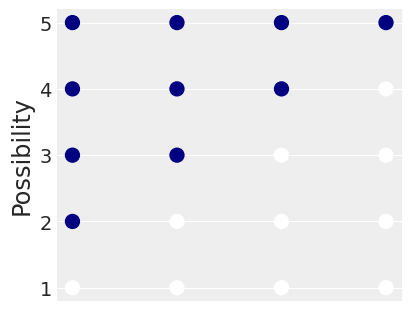

In [5]:
_, ax = plt.subplots(figsize=(4, 3))

ax.scatter(
    garden_melt["x"],
    garden_melt["possibility"],
    c=garden_melt["color"],
    s=100,
)

ax.set_ylabel("Possibility", fontsize="xx-large")
ax.set(xticks=[], yticks=range(5), yticklabels=range(1, 6))
plt.show()


In [6]:
from tabulate import tabulate


df = pd.DataFrame({"draw": [1, 2, 3], "marbles": [4, 4, 4]})
df["possibilities"] = df["marbles"] ** df["draw"]
table = tabulate(
    df,
    headers="keys",
    tablefmt="simple_outline",
    colalign=["right"] * 3,
    showindex=False,
)

print(table)


┌────────┬───────────┬─────────────────┐
│   draw │   marbles │   possibilities │
├────────┼───────────┼─────────────────┤
│      1 │         4 │               4 │
│      2 │         4 │              16 │
│      3 │         4 │              64 │
└────────┴───────────┴─────────────────┘


In [7]:
d = pd.DataFrame(
    {
        "position": np.concatenate(
            [
                np.arange(1, 4**1 + 1) / 4**0,
                np.arange(1, 4**2 + 1) / 4**1,
                np.arange(1, 4**3 + 1) / 4**2,
            ]
        ),
        "draw": np.repeat(np.arange(1, 4), repeats=(4**1, 4**2, 4**3)),
        "fill": np.tile(
            np.repeat(["navy", "white"], repeats=(1, 3)), 4**0 + 4**1 + 4**2
        ),
    }
)

d


,position,draw,fill
0,1.0000,1,navy
1,2.0000,1,white
2,3.0000,1,white
3,4.0000,1,white
4,0.2500,2,navy
...,...,...,...
79,3.7500,3,white
80,3.8125,3,navy
81,3.8750,3,white
82,3.9375,3,white


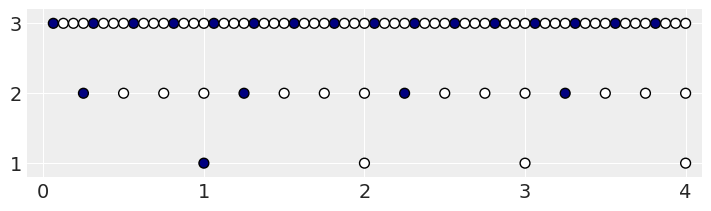

In [8]:
_, ax = plt.subplots(figsize=(7, 2))

ax.scatter(
    d["position"],
    d["draw"],
    c=d["fill"],
    s=50,
    edgecolors="black",
)
ax.set(
    xlim=(-0.1, 4.1),
    ylim=(0.8, 3.2),
    xticks=np.arange(5),
    yticks=[1, 2, 3],
)

plt.show()


In [9]:
d["denominator"] = d["draw"].map(
    dict(
        zip(
            [1, 2, 3],
            [0.5 / 4**0, 0.5 / 4**1, 0.5 / 4**2],
        )
    )
)

d


,position,draw,fill,denominator
0,1.0000,1,navy,0.50000
1,2.0000,1,white,0.50000
2,3.0000,1,white,0.50000
3,4.0000,1,white,0.50000
4,0.2500,2,navy,0.12500
...,...,...,...,...
79,3.7500,3,white,0.03125
80,3.8125,3,navy,0.03125
81,3.8750,3,white,0.03125
82,3.9375,3,white,0.03125


In [10]:
lines_1 = pd.DataFrame(
    {
        "x": np.repeat(np.arange(1, 4**1 + 1), repeats=4) - 0.5 / 4**0,
        "xend": np.arange(1, 4**2 + 1) / 4 - 0.5 / 4**1,
        "y": np.repeat(1, repeats=4**2),
        "yend": np.repeat(2, repeats=4**2),
    }
)

lines_1


,x,xend,y,yend
0,0.5,0.125,1,2
1,0.5,0.375,1,2
2,0.5,0.625,1,2
3,0.5,0.875,1,2
4,1.5,1.125,1,2
5,1.5,1.375,1,2
6,1.5,1.625,1,2
7,1.5,1.875,1,2
8,2.5,2.125,1,2
9,2.5,2.375,1,2


In [11]:
lines_2 = pd.DataFrame(
    {
        "x": np.repeat(np.arange(1, 4**2 + 1) / 4, repeats=4) - 0.5 / 4**1,
        "xend": np.arange(1, 4**3 + 1) / 4**2 - 0.5 / 4**2,
        "y": np.repeat(2, repeats=4**3),
        "yend": np.repeat(3, repeats=4**3),
    }
)

lines_2


,x,xend,y,yend
0,0.125,0.03125,2,3
1,0.125,0.09375,2,3
2,0.125,0.15625,2,3
3,0.125,0.21875,2,3
4,0.375,0.28125,2,3
...,...,...,...,...
59,3.625,3.71875,2,3
60,3.875,3.78125,2,3
61,3.875,3.84375,2,3
62,3.875,3.90625,2,3


In [12]:
d["position"] = d["position"] - d["denominator"]
d


,position,draw,fill,denominator
0,0.50000,1,navy,0.50000
1,1.50000,1,white,0.50000
2,2.50000,1,white,0.50000
3,3.50000,1,white,0.50000
4,0.12500,2,navy,0.12500
...,...,...,...,...
79,3.71875,3,white,0.03125
80,3.78125,3,navy,0.03125
81,3.84375,3,white,0.03125
82,3.90625,3,white,0.03125


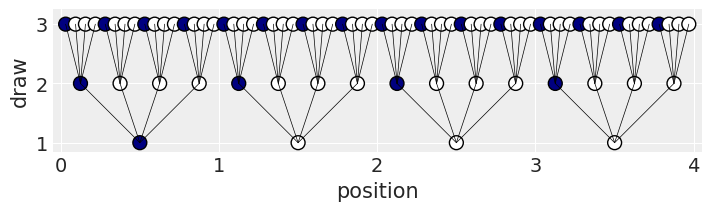

In [13]:
from matplotlib.lines import Line2D


_, ax = plt.subplots(figsize=(7, 2))

polar_factor = np.pi / 2

for _, row in lines_1.iterrows():
    ax.add_line(
        Line2D(
            [row["x"], row["xend"]],
            [row["y"], row["yend"]],
            color="black",
            linewidth=1 / 2,
        )
    )

for _, row in lines_2.iterrows():
    ax.add_line(
        Line2D(
            [row["x"], row["xend"]],
            [row["y"], row["yend"]],
            color="black",
            linewidth=1 / 2,
        )
    )


ax.scatter(
    d["position"],
    d["draw"],
    c=d["fill"],
    edgecolors="black",
    s=100,
)


ax.set(
    xlim=(-0.05, 4.05),
    ylim=(0.85, 3.25),
    xticks=np.arange(5),
    yticks=[1, 2, 3],
)

ax.set(xlabel="position", ylabel="draw")
plt.show()


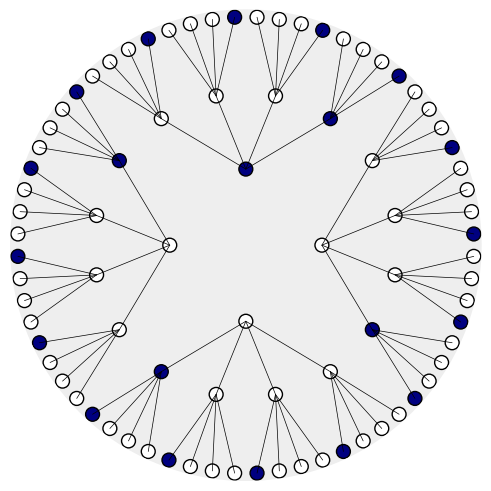

In [14]:
from matplotlib.lines import Line2D


_, ax = plt.subplots(subplot_kw={"projection": "polar"})

polar_factor = np.pi / 2

for _, row in lines_1.iterrows():
    ax.add_line(
        Line2D(
            [row["x"] * polar_factor, row["xend"] * polar_factor],
            [row["y"] * polar_factor, row["yend"] * polar_factor],
            color="black",
            linewidth=1 / 2,
        )
    )

for _, row in lines_2.iterrows():
    ax.add_line(
        Line2D(
            [row["x"] * polar_factor, row["xend"] * polar_factor],
            [row["y"] * polar_factor, row["yend"] * polar_factor],
            color="black",
            linewidth=1 / 2,
        )
    )


ax.scatter(
    d["position"] * polar_factor,
    d["draw"] * polar_factor,
    c=d["fill"],
    edgecolors="black",
    s=100,
)

ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set(
    xticks=np.arange(4) * polar_factor,
    xticklabels=[],
    yticks=[],
    theta_offset=polar_factor / 2,
)

plt.show()


In [15]:
# create the data
t = pd.DataFrame(
    {
        "d1": ["w", "b", "b", "b", "b"],
        "d2": ["w", "w", "b", "b", "b"],
        "d3": ["w", "w", "w", "b", "b"],
        "d4": ["w", "w", "w", "w", "b"],
    }
)

# apply the functions and calculate the product
t["blue1"] = np.sum(t.values == "b", axis=1)
t["white"] = np.sum(t.values == "w", axis=1)
t["blue2"] = np.sum(t.values == "b", axis=1)
t["product"] = t["blue1"] * t["white"] * t["blue2"]

t


,d1,d2,d3,d4,blue1,white,blue2,product
0,w,w,w,w,0,4,0,0
1,b,w,w,w,1,3,1,3
2,b,b,w,w,2,2,2,8
3,b,b,b,w,3,1,3,9
4,b,b,b,b,4,0,4,0


In [16]:
t1 = pd.DataFrame(
    {
        "Conjecture": "["
        + t["d1"]
        + " "
        + t["d2"]
        + " "
        + t["d3"]
        + " "
        + t["d4"]
        + "]",
        "Ways to produce [w b w]": t["blue1"].astype(str)
        + " * "
        + t["white"].astype(str)
        + " * "
        + t["blue2"].astype(str)
        + " = "
        + t["product"].astype(str),
    }
)

t1.style.set_properties(**{"text-align": "center", "font-family": "Andale Mono"})


,Conjecture,Ways to produce [w b w]
0,[w w w w],0 * 4 * 0 = 0
1,[b w w w],1 * 3 * 1 = 3
2,[b b w w],2 * 2 * 2 = 8
3,[b b b w],3 * 1 * 3 = 9
4,[b b b b],4 * 0 * 4 = 0


### 2.1.2 Combining other information

In [17]:
t2 = pd.DataFrame(
    {
        "Conjecture": "["
        + t["d1"]
        + " "
        + t["d2"]
        + " "
        + t["d3"]
        + " "
        + t["d4"]
        + "]",
        "Ways to produce [b]": t["blue1"],
        "Prior counts": t["product"],
    },
)

t2["New count"] = (
    t2["Ways to produce [b]"].astype(str)
    + " * "
    + t2["Prior counts"].astype(str)
    + " = "
    + (t2["Ways to produce [b]"] * t2["Prior counts"]).astype(str)
)

t2.style.set_properties(**{"text-align": "center", "font-family": "Andale Mono"})


,Conjecture,Ways to produce [b],Prior counts,New count
0,[w w w w],0,0,0 * 0 = 0
1,[b w w w],1,3,1 * 3 = 3
2,[b b w w],2,8,2 * 8 = 16
3,[b b b w],3,9,3 * 9 = 27
4,[b b b b],4,0,4 * 0 = 0


In [18]:
t3 = pd.DataFrame(
    {
        "Conjecture": "["
        + t["d1"]
        + " "
        + t["d2"]
        + " "
        + t["d3"]
        + " "
        + t["d4"]
        + "]",
        "Prior counts": t["blue1"] * t["product"],
        "Factory count": np.r_[np.array([0]), np.arange(3, -1, -1)],
    },
)

t3["New count"] = (
    t3["Prior counts"].astype(str)
    + " * "
    + t3["Factory count"].astype(str)
    + " = "
    + (t3["Prior counts"] * t3["Factory count"]).astype(str)
)

t3.style.set_properties(**{"text-align": "center", "font-family": "Andale Mono"})


,Conjecture,Prior counts,Factory count,New count
0,[w w w w],0,0,0 * 0 = 0
1,[b w w w],3,3,3 * 3 = 9
2,[b b w w],16,2,16 * 2 = 32
3,[b b b w],27,1,27 * 1 = 27
4,[b b b b],0,0,0 * 0 = 0


### 2.1.3 From counts to probability

#### Code 2.1

In [19]:
ways = np.array(t["product"])
ways / ways.sum()


array([0.  , 0.15, 0.4 , 0.45, 0.  ])

In [20]:
t4 = pd.DataFrame(
    {
        "Possible composition": "["
        + t["d1"]
        + " "
        + t["d2"]
        + " "
        + t["d3"]
        + " "
        + t["d4"]
        + "]",
        "*p*": t["blue1"] / 4,
        "Ways to produce data": ways,
        "Plausibility": ways / ways.sum(),
    },
)

t4.style.set_properties(
    **{"text-align": "center", "font-family": "Andale Mono"}
).format(precision=2)


,Possible composition,*p*,Ways to produce data,Plausibility
0,[w w w w],0.00,0,0.00
1,[b w w w],0.25,3,0.15
2,[b b w w],0.50,8,0.40
3,[b b b w],0.75,9,0.45
4,[b b b b],1.00,0,0.00


## 2.2 Building a model

### 2.2.2 Bayesian updating

In [21]:
toss = np.array(["w", "l", "w", "w", "w", "l", "w", "l", "w"])
n_trials = np.arange(1, 10)
n_success = np.cumsum(toss == "w")

df = pd.DataFrame({"toss": toss, "n_trials": n_trials, "n_success": n_success})

df


,toss,n_trials,n_success
0,w,1,1
1,l,2,1
2,w,3,2
3,w,4,3
4,w,5,4
5,l,6,4
6,w,7,5
7,l,8,5
8,w,9,6


In [22]:
import itertools

sequence_length = 50
# Create a list of values for p_water
p_water_values = np.linspace(0, 1, sequence_length)

# Create a list of all possible combinations of p_water and n_trials
expanded_grid = pd.DataFrame(
    list(itertools.product(n_trials, p_water_values)), columns=["n_trials", "p_water"]
)

# Merge the expanded grid with the original data frame
df_final = pd.merge(df, expanded_grid, on="n_trials")
df_final

,toss,n_trials,n_success,p_water
0,w,1,1,0.000000
1,w,1,1,0.020408
2,w,1,1,0.040816
3,w,1,1,0.061224
4,w,1,1,0.081633
...,...,...,...,...
445,w,9,6,0.918367
446,w,9,6,0.938776
447,w,9,6,0.959184
448,w,9,6,0.979592


In [23]:
df_final["lagged_n_trials"] = df_final.groupby("p_water")["n_trials"].shift(1)
df_final["lagged_n_success"] = df_final.groupby("p_water")["n_success"].shift(1)

df_final


,toss,n_trials,n_success,p_water,lagged_n_trials,lagged_n_success
0,w,1,1,0.000000,NaN,NaN
1,w,1,1,0.020408,NaN,NaN
2,w,1,1,0.040816,NaN,NaN
3,w,1,1,0.061224,NaN,NaN
4,w,1,1,0.081633,NaN,NaN
...,...,...,...,...,...,...
445,w,9,6,0.918367,8.0,5.0
446,w,9,6,0.938776,8.0,5.0
447,w,9,6,0.959184,8.0,5.0
448,w,9,6,0.979592,8.0,5.0


In [25]:
df_final["prior"] = np.where(
    df_final["n_trials"] == 1,
    0.5,
    stats.binom.pmf(
        df_final["lagged_n_success"],
        df_final["lagged_n_trials"],
        df_final["p_water"],
    ),
)

df_final["likelihood"] = stats.binom.pmf(
    df_final["n_success"],
    df_final["n_trials"],
    df_final["p_water"],
)

df_final["strip"] = "n = " + df_final["n_trials"].astype(str)

df_final


,toss,n_trials,n_success,p_water,lagged_n_trials,lagged_n_success,prior,likelihood,strip
0,w,1,1,0.000000,NaN,NaN,0.500000,0.000000,n = 1
1,w,1,1,0.020408,NaN,NaN,0.500000,0.020408,n = 1
2,w,1,1,0.040816,NaN,NaN,0.500000,0.040816,n = 1
3,w,1,1,0.061224,NaN,NaN,0.500000,0.061224,n = 1
4,w,1,1,0.081633,NaN,NaN,0.500000,0.081633,n = 1
...,...,...,...,...,...,...,...,...,...
445,w,9,6,0.918367,8.0,5.0,0.019900,0.027414,n = 9
446,w,9,6,0.938776,8.0,5.0,0.009371,0.013195,n = 9
447,w,9,6,0.959184,8.0,5.0,0.003092,0.004448,n = 9
448,w,9,6,0.979592,8.0,5.0,0.000429,0.000631,n = 9


In [26]:
df_final["prior"] = df_final.groupby("n_trials", group_keys=False)["prior"].apply(
    lambda x: x / x.sum()
)

df_final["likelihood"] = df_final.groupby("n_trials", group_keys=False)[
    "likelihood"
].apply(lambda x: x / x.sum())

df_final


,toss,n_trials,n_success,p_water,lagged_n_trials,lagged_n_success,prior,likelihood,strip
0,w,1,1,0.000000,NaN,NaN,0.020000,0.000000,n = 1
1,w,1,1,0.020408,NaN,NaN,0.020000,0.000816,n = 1
2,w,1,1,0.040816,NaN,NaN,0.020000,0.001633,n = 1
3,w,1,1,0.061224,NaN,NaN,0.020000,0.002449,n = 1
4,w,1,1,0.081633,NaN,NaN,0.020000,0.003265,n = 1
...,...,...,...,...,...,...,...,...,...
445,w,9,6,0.918367,8.0,5.0,0.003655,0.005595,n = 9
446,w,9,6,0.938776,8.0,5.0,0.001721,0.002693,n = 9
447,w,9,6,0.959184,8.0,5.0,0.000568,0.000908,n = 9
448,w,9,6,0.979592,8.0,5.0,0.000079,0.000129,n = 9


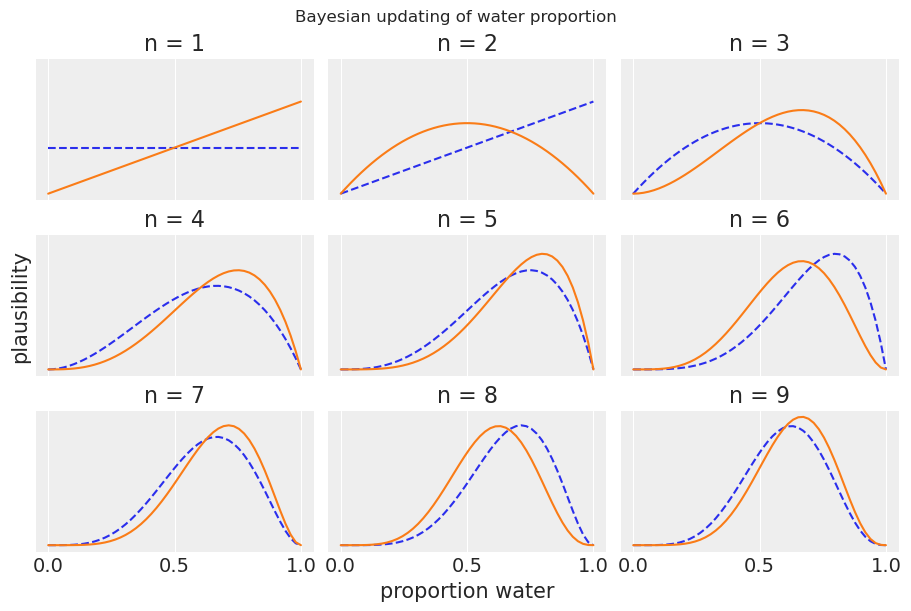

In [28]:
_, axes = plt.subplots(3, 3, figsize=(9, 6), sharex=True, sharey=True)

for (ix, group), ax in zip(df_final.groupby("strip"), axes.flatten()):
    ax.plot(group["p_water"], group["prior"], linestyle="--")
    ax.plot(group["p_water"], group["likelihood"])
    ax.set_title(group["strip"].unique()[0])
    ax.set_yticks([])
    idx = group["n_trials"]
    ax.set_xticks([0, 0.5, 1.0])

axes[1, 0].set_ylabel("plausibility")
axes[2, 1].set_xlabel("proportion water")

plt.suptitle("Bayesian updating of water proportion")
plt.show()


## 2.3 Components of the model

#### Code 2.2

$$Pr(w \mid n, p) =  \frac{n!}{w!(n − w)!} p^w (1 − p)^{n−w}$$

The probability of observing six W’s in nine tosses — below a value of $p=0.5$.


In [29]:
stats.binom.pmf(6, n=9, p=0.5)

0.16406250000000003

#### Code 2.3 and 2.5

Computing the posterior using a grid approximation.

In the book, the following code is not inside a function, but this way it is easier to play with different parameters.


In [23]:
def uniform_prior(grid_points):
    """
    Returns Uniform prior density

            Parameters:
                grid_points (numpy.array): Array of prior values

            Returns:
                density (numpy.array): Uniform density of prior values
    """
    return np.repeat(5, grid_points)


def truncated_prior(grid_points, trunc_point=0.5):
    """
    Returns Truncated prior density

            Parameters:
                grid_points (numpy.array): Array of prior values
                trunc_point (double): Value where the prior is truncated

            Returns:
                density (numpy.array): Truncated density of prior values
    """
    return (np.linspace(0, 1, grid_points) >= trunc_point).astype(int)


def double_exp_prior(grid_points):
    """
    Returns Double Exponential prior density

            Parameters:
                grid_points (numpy.array): Array of prior values

            Returns:
                density (numpy.array): Double Exponential density of prior values
    """
    return np.exp(-5 * abs(np.linspace(0, 1, grid_points) - 0.5))


In [24]:
def binom_post_grid_approx(prior_func, grid_points=5, success=6, tosses=9):
    """
    Returns the grid approximation of posterior distribution with binomial likelihood.

            Parameters:
                    prior_func (function): A function that returns the likelihood of the prior
                    grid_points (int): Number of points in the prior grid
                    successes (int): Number of successes
                    tosses (int): number of tosses

            Returns:
                    p_grid (numpy.array): Array of prior values
                    posterior (numpy.array): Likelihood (density) of prior values
    """
    # define grid
    p_grid = np.linspace(0, 1, grid_points)

    # define prior
    prior = prior_func(grid_points)

    # compute likelihood at each point in the grid
    likelihood = stats.binom.pmf(success, tosses, p_grid)

    # compute product of likelihood and prior
    unstd_posterior = likelihood * prior

    # standardize the posterior, so it sums to 1
    posterior = unstd_posterior / (unstd_posterior.sum() / grid_points)
    return p_grid, posterior


#### Code 2.3

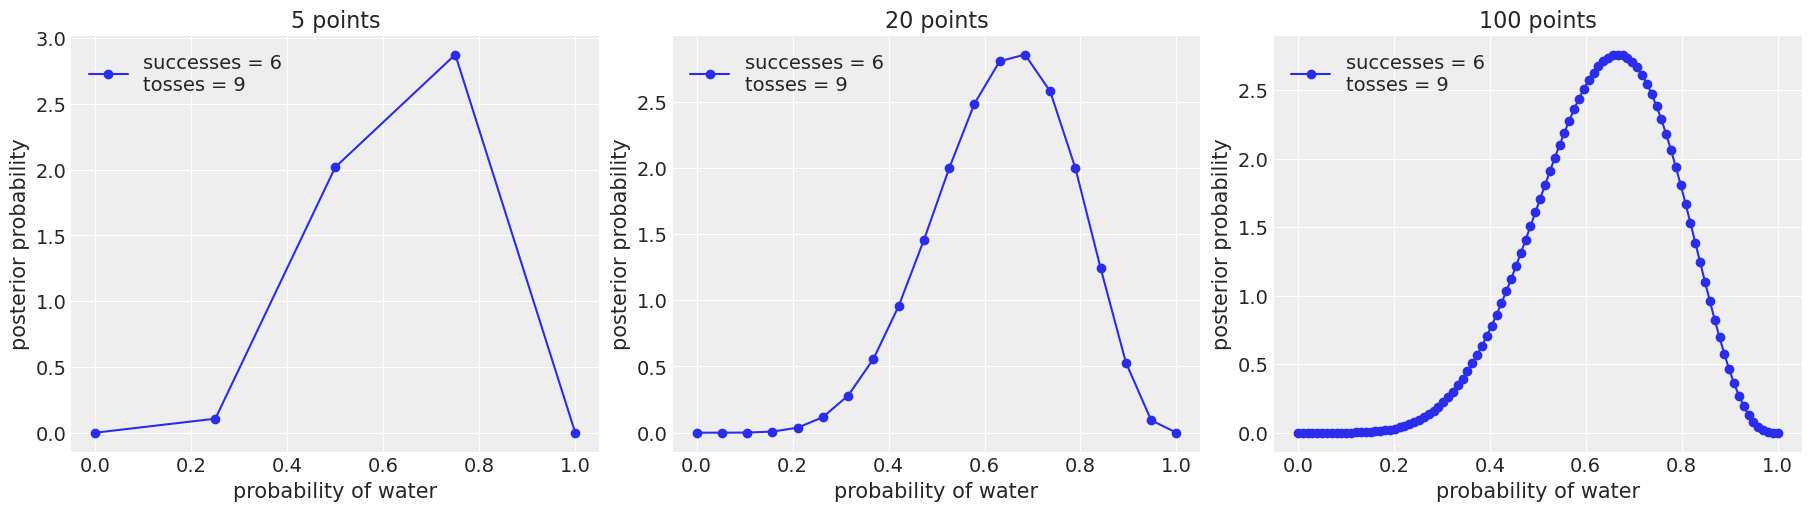

In [25]:
w, n = 6, 9

points = (5, 20, 100)

_, ax = plt.subplots(1, len(points), figsize=(6 * len(points), 5))

for idx, ps in enumerate(points):
    p_grid, posterior = binom_post_grid_approx(uniform_prior, ps, w, n)
    ax[idx].plot(p_grid, posterior, "o-", label=f"successes = {w}\ntosses = {n}")
    ax[idx].set_xlabel("probability of water")
    ax[idx].set_ylabel("posterior probability")
    ax[idx].set_title(f"{ps} points")
    ax[idx].legend(loc=0)


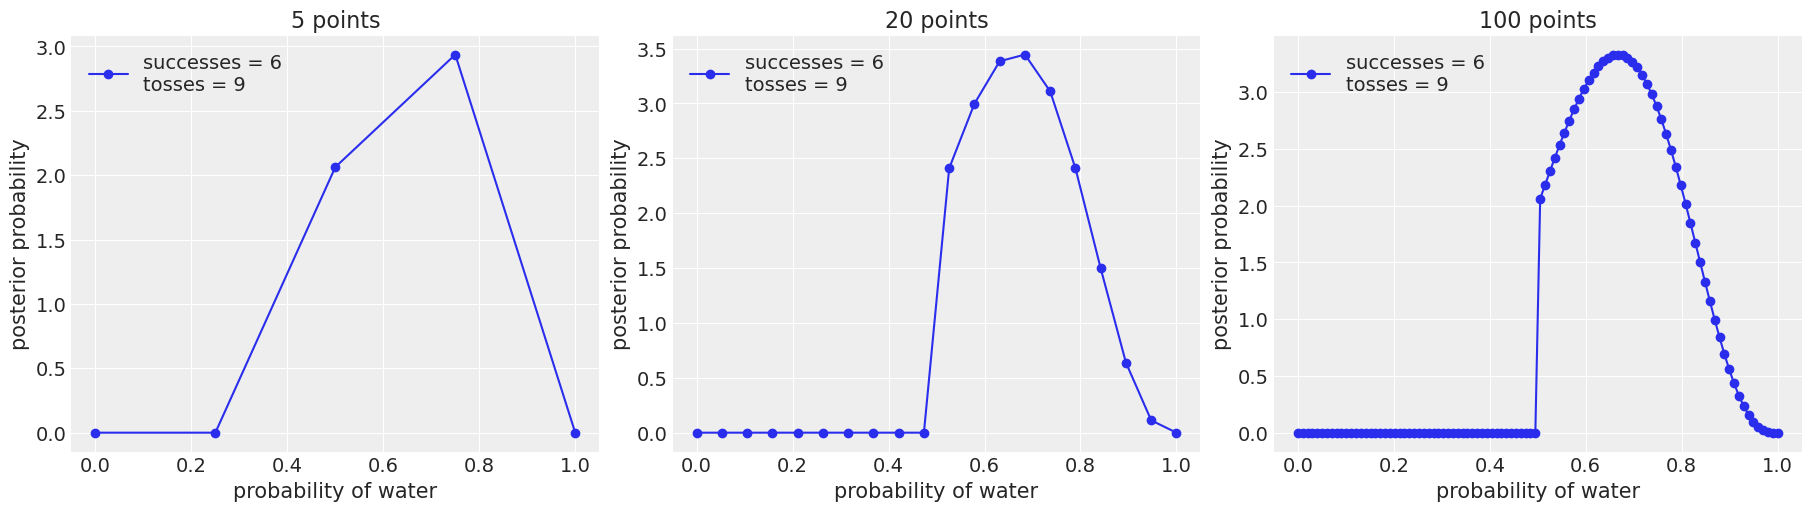

In [26]:
_, ax = plt.subplots(1, len(points), figsize=(6 * len(points), 5))

for idx, ps in enumerate(points):
    p_grid, posterior = binom_post_grid_approx(truncated_prior, ps, w, n)
    ax[idx].plot(p_grid, posterior, "o-", label=f"successes = {w}\ntosses = {n}")
    ax[idx].set_xlabel("probability of water")
    ax[idx].set_ylabel("posterior probability")
    ax[idx].set_title(f"{ps} points")
    ax[idx].legend(loc=0)


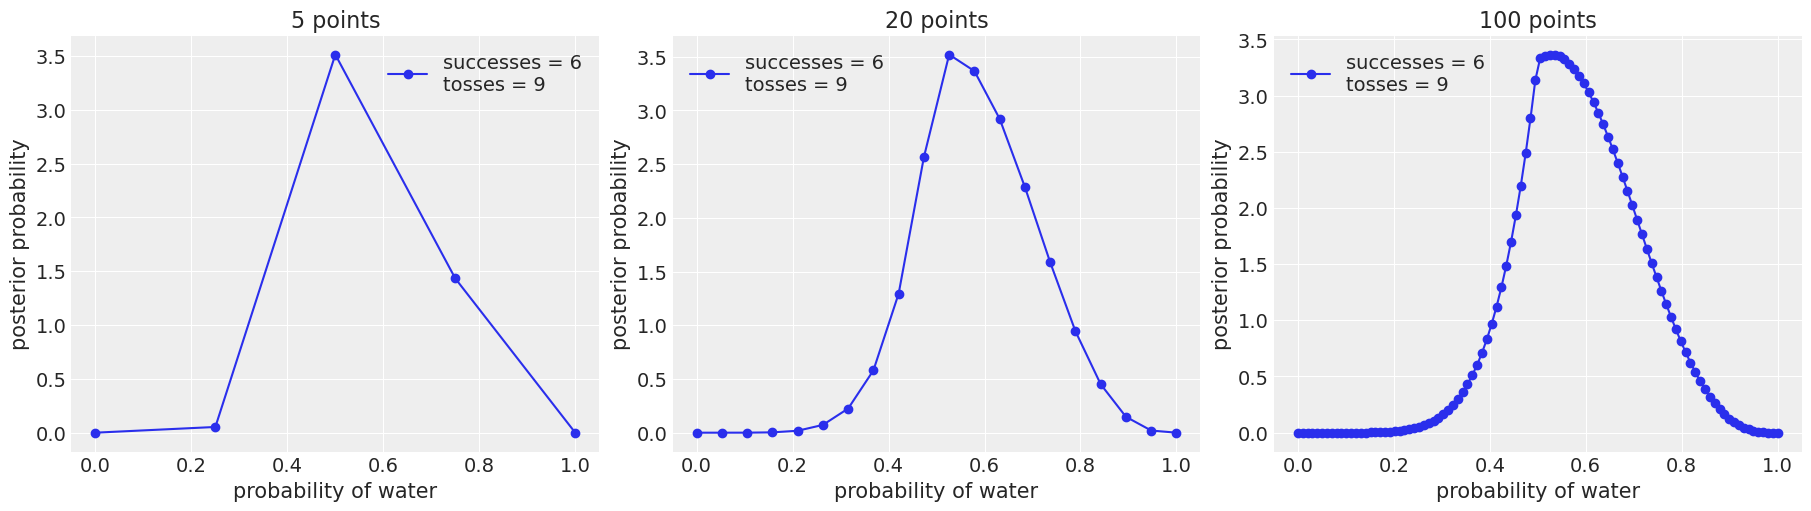

In [27]:
_, ax = plt.subplots(1, len(points), figsize=(6 * len(points), 5))

for idx, ps in enumerate(points):
    p_grid, posterior = binom_post_grid_approx(double_exp_prior, ps, w, n)
    ax[idx].plot(p_grid, posterior, "o-", label=f"successes = {w}\ntosses = {n}")
    ax[idx].set_xlabel("probability of water")
    ax[idx].set_ylabel("posterior probability")
    ax[idx].set_title(f"{ps} points")
    ax[idx].legend(loc=0)


#### Code 2.6

Computing the posterior using the quadratic approximation (quad).


In [28]:
np.repeat((0, 1), (3, 6))


array([0, 0, 0, 1, 1, 1, 1, 1, 1])

In [29]:
data = np.repeat((0, 1), (3, 6))

with pm.Model() as normal_approximation:
    p = pm.Uniform("p", 0, 1)  # uniform priors
    w = pm.Binomial("w", n=len(data), p=p, observed=data.sum())  # binomial likelihood
    mean_q = pm.find_MAP()

    p_value = normal_approximation.rvs_to_values[p]
    p_value.tag.transform = None
    p_value.name = p.name

    std_q = ((1 / pm.find_hessian(mean_q, vars=[p])) ** 0.5)[0]

# display summary of quadratic approximation
print("Mean, Standard deviation\np {:.2}, {:.2}".format(mean_q["p"], std_q[0]))



Mean, Standard deviation
p 0.67, 0.64


In [30]:
# Compute the 89% percentile interval
norm = stats.norm(mean_q, std_q)
prob = 0.89
z = stats.norm.ppf([(1 - prob) / 2, (1 + prob) / 2])
pi = mean_q["p"] + std_q * z
pi = [0.055, 0.945]
print(f"5.5%, 94.5% \n{pi[0]:.2}, {pi[1]:.2}")


5.5%, 94.5% 
0.055, 0.94


#### Code 2.7

Text(0.5, 0, 'Proportion water')

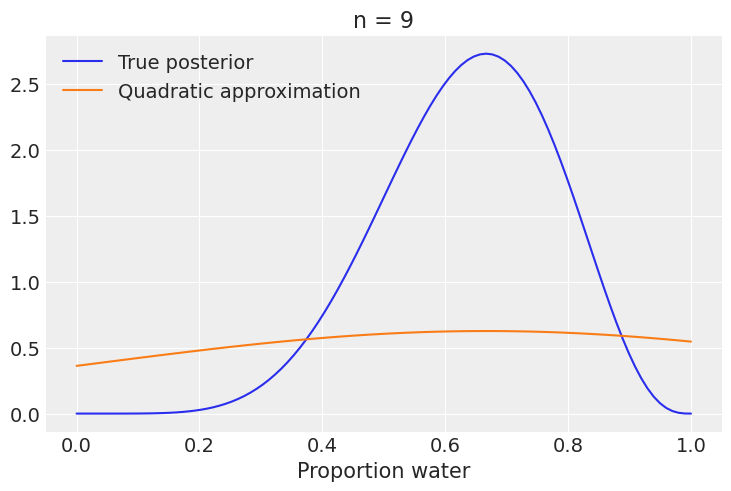

In [31]:
# analytical calculation
w, n = 6, 9
x = np.linspace(0, 1, 100)
plt.plot(x, stats.beta.pdf(x, w + 1, n - w + 1), label="True posterior")

# quadratic approximation
plt.plot(x, stats.norm.pdf(x, mean_q["p"], std_q), label="Quadratic approximation")
plt.legend(loc=0)

plt.title(f"n = {n}")
plt.xlabel("Proportion water")


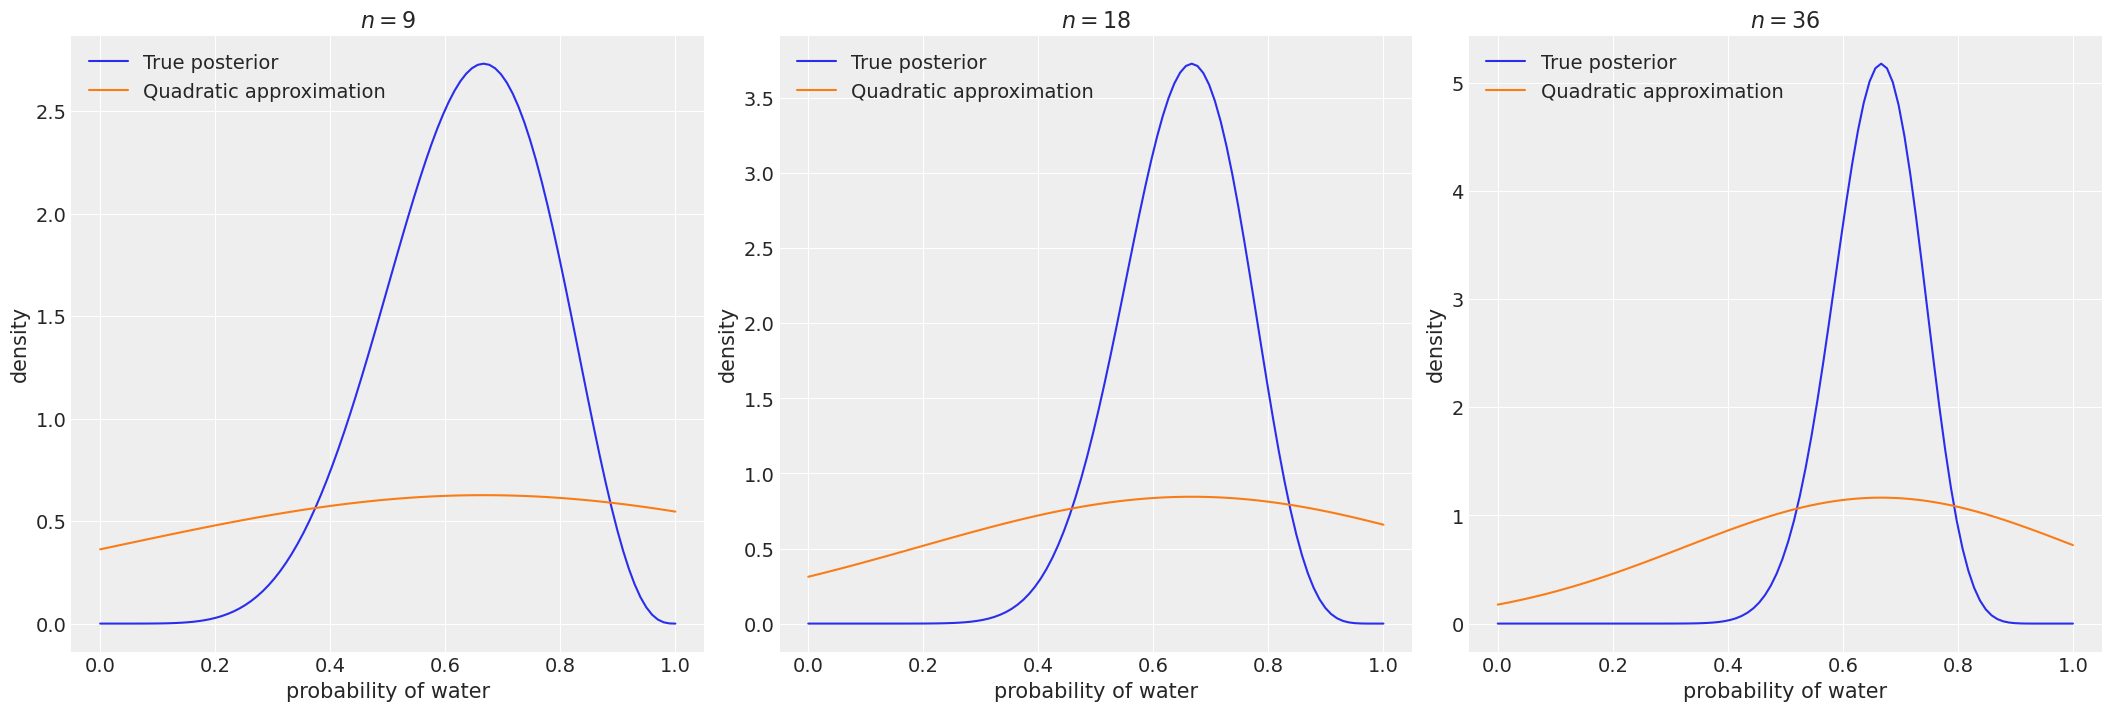

In [32]:
# Figure 2.8
x = np.linspace(0, 1, 100)
w, n = [6, 12, 24], [9, 18, 36]

fig, ax = plt.subplots(1, 3, figsize=(21, 7))

for idx, ps in enumerate(zip(w, n)):
    data = np.repeat((0, 1), (ps[1] - ps[0], ps[0]))
    with pm.Model() as normal_approximation:
        p = pm.Uniform("p", 0, 1)  # uniform priors
        w = pm.Binomial(
            "w", n=len(data), p=p, observed=data.sum()
        )  # binomial likelihood
        mean_q = pm.find_MAP()

        p_value = normal_approximation.rvs_to_values[p]
        p_value.tag.transform = None
        p_value.name = p.name

        std_q = ((1 / pm.find_hessian(mean_q, vars=[p])) ** 0.5)[0]

    ax[idx].plot(
        x, stats.beta.pdf(x, ps[0] + 1, ps[1] - ps[0] + 1), label="True posterior"
    )
    ax[idx].plot(
        x, stats.norm.pdf(x, mean_q["p"], std_q), label="Quadratic approximation"
    )
    ax[idx].set_xlabel("probability of water")
    ax[idx].set_ylabel("density")
    ax[idx].set_title(f"$n={ps[1]}$")
    ax[idx].legend(loc="upper left")


#### Code 2.8

In [33]:
n_samples = 1000
p = np.zeros(n_samples)
p[0] = 0.5
W = 6
L = 3
for i in range(1, n_samples):
    p_new = stats.norm(p[i - 1], 0.1).rvs(1)
    if p_new < 0:
        p_new = -p_new
    if p_new > 1:
        p_new = 2 - p_new
    q0 = stats.binom.pmf(W, n=W + L, p=p[i - 1])
    q1 = stats.binom.pmf(W, n=W + L, p=p_new)
    p[i] = p_new if stats.uniform.rvs(0, 1) < q1 / q0 else p[i - 1]


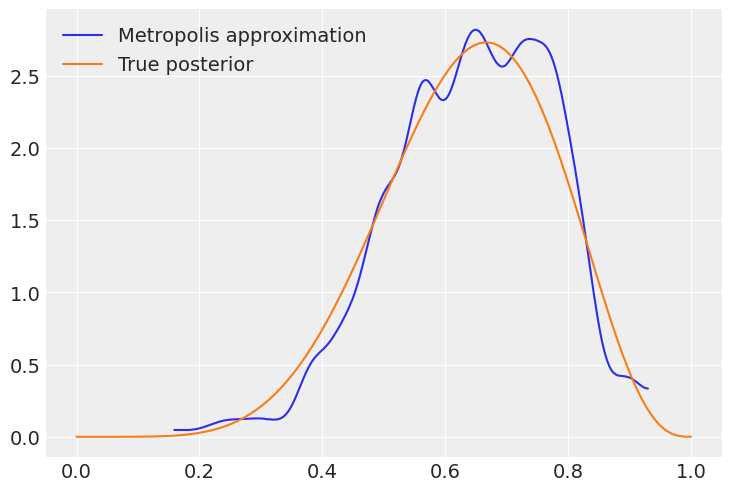

In [34]:
az.plot_kde(p, label="Metropolis approximation")

x = np.linspace(0, 1, 100)
plt.plot(x, stats.beta.pdf(x, W + 1, L + 1), "C1", label="True posterior")
plt.legend()
